# BERT LLM Hallucination Detector

### Imports

In [13]:
import os
import json
import time
import ast
import unicodedata
from datetime import datetime
import random
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
from dotenv import load_dotenv
from tavily import TavilyClient
from langdetect import detect, DetectorFactory
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
12.8
True
NVIDIA GeForce RTX 5070 Laptop GPU


### Step 2: Data Loading

In [14]:
dataset = load_dataset("Helsinki-NLP/mu-shroom", "all")

# Access splits
train = dataset["train_unlabeled"]
val = dataset["validation"]
test = dataset["test"]

# add indices to the dataset
def add_id(example, idx):
    """
    Attach a sequential integer id to a dataset row.

    `train_unlabeled` ships with `id = None` on every row, so an id has to be
    assigned before annotations can be matched back to their samples.

    Args:
        example (dict): one dataset row.
        idx (int): the row index, supplied by
            `Dataset.map(..., with_indices=True)`.

    Returns:
        dict: the same row with `example["id"]` set to `idx`.

    Example:
        >>> train = train.map(add_id, with_indices=True)
        >>> train[0]["id"]
        0
    """
    example["id"] = idx
    return example

# normalize the characters in the dataset to avoid issues with special characters
def normalize_text(text):
    """
    Normalize Unicode form, curly quotes and invisible spaces in a string.

    Applies NFC composition, rewrites typographic quotes to ASCII ones, strips
    zero-width characters and trims surrounding whitespace.

    WARNING: this changes `len(text)`, which invalidates character offsets. Run
    it only on `train_unlabeled`, where the labels are derived *after*
    normalization. Never run it on `validation` / `test`, whose gold offsets
    index the raw string.

    Args:
        text (str | None): the string to clean; `None` becomes `""`.

    Returns:
        str: the normalized string.

    Example:
        >>> normalize_text('  He said "hello"  ')
        'He said "hello"'
    """
    if text is None:
        return ""

    # Normalize Unicode representation
    text = unicodedata.normalize("NFC", text)

    # Normalize quotation marks/apostrophes
    replacements = {
        "’": "'",
        "‘": "'",
        "“": '"',
        "”": '"',
        "„": '"',
        "‹": "'",
        "›": "'",
        "\u00A0": " ",  # non-breaking space
        "\u200B": "",   # zero-width space
        "\u200D": "",   # zero-width joiner
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text.strip()


train = train.map(
    add_id,
    with_indices=True
)

In [15]:
train.__len__

<bound method Dataset.__len__ of Dataset({
    features: ['id', 'lang', 'model_input', 'model_output_text', 'model_id', 'wikipedia_url', 'soft_labels', 'hard_labels', 'model_output_logits', 'model_output_tokens', 'annotations'],
    num_rows: 3351
})>

#### 6.3 Annotation of soft and hard labels for llm output

8. Load annotated spans from JSONL and make a huggingface dataset later*

#### Label aggregation settings

In [16]:
# we have some rows which would have 2 votes becuse of rate limits so drop those
MIN_VALID_VOTES = 4
HARD_LABEL_THRESHOLD = 0.5

In [17]:
import json

# load the annotations from jsonl file
def load_annotations(annotation_file):
    """
    Read an append-only annotations JSONL file into a list of records.
    """
    annotations = []

    with open(annotation_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            annotations.append(json.loads(line))

    return annotations


def valid_votes(annotation):
    """
    Return only the votes of an annotation that actually reached a model.
    """
    return [
        vote
        for vote in annotation["metadata"]
        if "error" not in vote
    ]


def filter_annotations(annotations, min_valid_votes=MIN_VALID_VOTES):
    """
    Split annotations into those with enough surviving votes and those without.
    """
    kept = []
    dropped = []

    for ann in annotations:

        if len(valid_votes(ann)) >= min_valid_votes:
            kept.append(ann)

        else:
            dropped.append(ann)

    return kept, dropped


annotations = load_annotations(
    "annotations.jsonl"
)

annotations, dropped_annotations = filter_annotations(
    annotations,
    min_valid_votes=MIN_VALID_VOTES
)

# filter the data based on annotations found in the annotations.jsonl file
annotated_ids = {ann["sample_id"] for ann in annotations}
filtered_data = train.filter(lambda x: x["id"] in annotated_ids)

print(f"Number of annotations kept: {len(annotations)}")
print(f"Number of annotations dropped (fewer than {MIN_VALID_VOTES} valid votes): {len(dropped_annotations)}")
print(f"Number of filtered training samples: {len(filtered_data)}")

# how much of the ensemble actually survived
vote_counts = [len(valid_votes(ann)) for ann in annotations]
print(f"Valid votes per kept sample: min={min(vote_counts)}, max={max(vote_counts)}")
print(f"Samples that lost at least one vote to an API error: "
      f"{sum(1 for ann in annotations if len(valid_votes(ann)) < len(ann['metadata']))}")

annotations_dict = {
    ann["sample_id"]: ann
    for ann in annotations
}

Number of annotations kept: 3327
Number of annotations dropped (fewer than 4 valid votes): 24
Number of filtered training samples: 3327
Valid votes per kept sample: min=4, max=18
Samples that lost at least one vote to an API error: 419


9. Convert detected text spans → character-level labels

In [18]:
def spans_to_character_labels(text, spans):
    """
    Turn a list of hallucinated span strings into a per-character 0/1 array.

    Each span is located in `text` with `str.find`, so two silent losses are
    possible and worth remembering: only the **first** occurrence of a repeated
    span is labelled, and a span the model paraphrased instead of copying
    verbatim is dropped entirely (~4% of spans in the current file).

    Args:
        text (str): the answer the spans were copied from.
        spans (list[str]): span strings returned by an annotator model.

    Returns:
        numpy.ndarray: `int8` array of length `len(text)`, 1 where hallucinated.

    Example:
        >>> spans_to_character_labels("abc def", ["def"]).tolist()
        [0, 0, 0, 0, 1, 1, 1]
    """
    labels = np.zeros(len(text), dtype=np.int8)

    for span in spans:

        if not span:
            continue

        start = text.find(span)

        if start == -1:
            continue

        end = start + len(span)

        labels[start:end] = 1

    return labels


def labels_to_spans(text, soft_char_labels, threshold=HARD_LABEL_THRESHOLD):
    """
    Convert per-character soft labels into the official Mu-SHROOM span format.

    Bridges the two label representations in play: ours (one probability per
    character) and the official one (lists of spans). Both outputs are derived
    from the same array, so they can never disagree with each other.

    `soft_labels` keeps the vote fraction of every non-zero run; `hard_labels`
    is that array binarised at `threshold` and merged into contiguous spans.
    Zero-probability runs are omitted from `soft_labels`: the official scorer
    initialises its vector to 0.0 and fills in only the segments it is given, so
    dropping them is equivalent and far smaller on disk.

    Args:
        text (str): the answer the labels index into; used to validate length.
        soft_char_labels (Sequence[float]): one probability per character - the
            fraction of valid votes that marked that character.
        threshold (float): cutoff for the hard labels. Compared with `>=`, to
            match `apply_character_labels_to_dataset`.

    Returns:
        dict: {
            "soft_labels": [{"start": int, "end": int, "prob": float}, ...],
            "hard_labels": [[start, end], ...],
        }
        Both end-exclusive, both in the schema the gold splits use.

    Raises:
        ValueError: if the label array length does not match the text length.

    Example:
        >>> labels_to_spans("abcdef", [0.0, 0.83, 0.83, 0.0, 0.5, 0.5])
        {'soft_labels': [{'start': 1, 'end': 3, 'prob': 0.83},
                         {'start': 4, 'end': 6, 'prob': 0.5}],
         'hard_labels': [[1, 3]]}
    """
    if len(soft_char_labels) != len(text):
        raise ValueError(
            f"label/text length mismatch: {len(soft_char_labels)} labels "
            f"for {len(text)} characters"
        )

    length = len(soft_char_labels)

    # soft labels: run-length encode, skipping the zero runs
    soft_labels = []

    run_start = 0

    for index in range(1, length + 1):

        if index == length or soft_char_labels[index] != soft_char_labels[run_start]:

            prob = float(soft_char_labels[run_start])

            if prob > 0.0:
                soft_labels.append({
                    "start": run_start,
                    "end": index,
                    "prob": prob,
                })

            run_start = index

    # hard labels: merge contiguous runs at or above the threshold
    hard_labels = []

    span_start = None

    for index, prob in enumerate(soft_char_labels):

        if prob >= threshold and span_start is None:
            span_start = index

        elif prob < threshold and span_start is not None:
            hard_labels.append([span_start, index])
            span_start = None

    if span_start is not None:
        hard_labels.append([span_start, length])

    return {
        "soft_labels": soft_labels,
        "hard_labels": hard_labels,
    }


def spans_to_character_array(text, hard_labels):
    """
    Expand official `[start, end]` spans back into a per-character 0/1 array.

    The exact inverse of the `hard_labels` half of `labels_to_spans`. Needed
    because the token classifier aligns labels by slicing characters, while the
    dataset stores spans. Ends are clamped to the text length defensively.

    Args:
        text (str): the answer the spans index into.
        hard_labels (list): `[[start, end], ...]`, end-exclusive.

    Returns:
        numpy.ndarray: `int64` array of length `len(text)`, 1 where hallucinated.

    Example:
        >>> spans_to_character_array("abcdef", [[1, 3]]).tolist()
        [0, 1, 1, 0, 0, 0]
        >>> spans_to_character_array("abcdef", []).tolist()
        [0, 0, 0, 0, 0, 0]
    """
    labels = np.zeros(len(text), dtype=np.int64)

    for start, end in hard_labels:
        labels[int(start):min(int(end), len(text))] = 1

    return labels


def apply_character_labels_to_dataset(dataset, annotations, threshold=HARD_LABEL_THRESHOLD):
    """
    Aggregate the annotator ensemble into official-format soft and hard labels.

    For every row, each **valid** vote is rendered as a 0/1 character array and
    the arrays are averaged. That per-character mean is then converted straight
    into the official Mu-SHROOM schema by `labels_to_spans`, so what lands in
    the dataset is `[{start, end, prob}, ...]` and `[[start, end], ...]` - the
    same shape as the gold `validation` and `test` splits, not a per-character
    array wearing the same field names.

    Errored votes are excluded from the average entirely rather than counted as
    zeros -- counting them dragged 243 rows to all-zero labels despite unanimous
    agreement among the votes that succeeded.

    Two extra columns are written so any downstream filter or weighting can see
    how much of the ensemble a row is actually based on.

    Args:
        dataset (datasets.Dataset): rows carrying `id` and `model_output_text`.
        annotations (list[dict]): records, already passed through
            `filter_annotations` so every row has enough valid votes.
        threshold (float): soft-label cutoff for binarization.

    Returns:
        datasets.Dataset: the same rows plus `soft_labels`, `hard_labels`,
        `n_valid_votes` and `n_votes`.

    Raises:
        ValueError: if a row has no valid votes at all (filter first).

    Example:
        >>> filtered_train = apply_character_labels_to_dataset(
        ...     filtered_data,
        ...     annotations,
        ... )
        >>> filtered_train[0]["n_valid_votes"]
        18
        >>> filtered_train[0]["hard_labels"][:1]
        [[19, 35]]
    """
    annotations_dict = {
        ann["sample_id"]: ann
        for ann in annotations
    }

    def add_labels(example):
        """
        Aggregate one row's votes into official-format soft and hard labels.

        Closes over `annotations_dict` and `threshold` so it can be handed
        straight to `Dataset.map`.

        Args:
            example (dict): a row with `id` and `model_output_text`.

        Returns:
            dict: the row plus `soft_labels` ([{start, end, prob}, ...]),
            `hard_labels` ([[start, end], ...]), `n_valid_votes` and `n_votes`.

        Example:
            >>> row = add_labels({"id": 822, "model_output_text": text})
            >>> row["n_valid_votes"], row["n_votes"]
            (4, 6)
        """
        ann = annotations_dict[example["id"]]

        text = example["model_output_text"]

        # drop votes that failed with an API error: an empty span list caused
        # by a 429 is not evidence that the text is clean
        votes = valid_votes(ann)

        if not votes:
            raise ValueError(
                f"sample {example['id']} has no valid votes - run "
                f"filter_annotations() before aggregating"
            )

        all_character_labels = [
            spans_to_character_labels(text, vote.get("spans", []))
            for vote in votes
        ]

        label_matrix = np.stack(all_character_labels)

        # denominator is the number of votes that survived, not the number cast
        soft_char_labels = label_matrix.mean(axis=0).tolist()

        # convert to the official schema before anything is saved to disk
        official = labels_to_spans(text, soft_char_labels, threshold=threshold)

        example["soft_labels"] = official["soft_labels"]
        example["hard_labels"] = official["hard_labels"]
        example["n_valid_votes"] = len(votes)
        example["n_votes"] = len(ann["metadata"])
        example["reference_ans"] = ann["reference_answer"]

        return example

    return dataset.map(add_labels)

In [19]:
filtered_train = apply_character_labels_to_dataset(
    filtered_data,
    annotations
)

In [20]:
sample = filtered_train[0]

print(sample["model_output_text"])

print("\nSoft:")
print(sample["soft_labels"])

print("\nHard:")
print(sample["hard_labels"])

 Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna. 

Soft:
[{'start': 1, 'prob': 0.6666666666666666, 'end': 6}, {'start': 6, 'prob': 1.0, 'end': 99}, {'start': 99, 'prob': 0.3888888888888889, 'end': 100}]

Hard:
[[1, 99]]


Save Hugging face datase
but we need this format
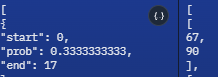

In [21]:
# Inspect one row in the official format, and confirm the schema matches the
# gold splits. If the two feature blocks below print the same structure, this
# dataset is a drop-in match for Helsinki-NLP/mu-shroom.
sample = filtered_train[9]

print(sample["model_output_text"])

print("\nsoft_labels:", sample["soft_labels"])
print("hard_labels:", sample["hard_labels"])

print("\nhallucinated spans:")
for start, end in sample["hard_labels"]:
    print(f"  [{start}:{end}] {sample['model_output_text'][start:end]!r}")

print("\n--- schema check ---")
print("ours  soft:", filtered_train.features["soft_labels"])
print("gold  soft:", val.features["soft_labels"])
print("ours  hard:", filtered_train.features["hard_labels"])
print("gold  hard:", val.features["hard_labels"])

 The Arts & Humanites CiteSeer is no longer being maintained. It was a great resource while it lasted, but the index has been superseded by the more comprehensive Web of Science. 

soft_labels: [{'start': 1, 'prob': 1.0, 'end': 60}, {'start': 60, 'prob': 0.5555555555555556, 'end': 61}, {'start': 107, 'prob': 0.9444444444444444, 'end': 177}, {'start': 177, 'prob': 0.1111111111111111, 'end': 178}]
hard_labels: [[1, 61], [107, 177]]

hallucinated spans:
  [1:61] 'The Arts & Humanites CiteSeer is no longer being maintained.'
  [107:177] 'the index has been superseded by the more comprehensive Web of Science'

--- schema check ---
ours  soft: List({'start': Value('int64'), 'prob': Value('float64'), 'end': Value('int64')})
gold  soft: List({'start': Value('int64'), 'prob': Value('float64'), 'end': Value('int64')})
ours  hard: List(List(Value('int64')))
gold  hard: List(List(Value('int64')))


In [22]:
filtered_train.save_to_disk(
    "annotated_train_dataset_reference_answers"
)

Saving the dataset (0/1 shards):   0%|          | 0/3327 [00:00<?, ? examples/s]

load the dataset and annotations

In [25]:
from datasets import load_from_disk

dataset = load_from_disk(
    "annotated_train_dataset_reference_answers"
)

In [26]:
dataset[0]

{'id': 0,
 'lang': 'EN',
 'model_input': 'Do all arthropods have antennae?',
 'model_output_text': ' Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna. ',
 'model_id': 'togethercomputer/Pythia-Chat-Base-7B',
 'wikipedia_url': None,
 'soft_labels': [{'start': 1, 'prob': 0.6666666666666666, 'end': 6},
  {'start': 6, 'prob': 1.0, 'end': 99},
  {'start': 99, 'prob': 0.3888888888888889, 'end': 100}],
 'hard_labels': [[1, 99]],
 'model_output_logits': [-2.57427001,
  5.1865358353,
  5.4173498154,
  2.3298389912,
  6.6413722038,
  3.5858919621,
  10.0333786011,
  4.0347309113,
  2.5324678421,
  0.595354557,
  2.0120403767,
  1.8963916302,
  6.8019108772,
  6.2508711815,
  4.6549735069,
  2.6137938499,
  -3.9706561565,
  7.5047488213,
  4.2792539597,
  3.0500841141,
  -0.4772415757,
  3.1624026299,
  13.7479448318,
  -1.7824890614,
  3.9432423115,
  4.9513559341,
  4.3375749588,
  14.8357839584],
 'model_output_tokens': ['ĠYes',
  ',',
  'Ġall',